In [1]:
suppressPackageStartupMessages(library(tidyverse))
library(here)

options(box.path = here())
box::use(r / load)

r_out <- here("reports", "figures")
model_path <- here("data", "models")

PLOT_WIDTH <- 9
PLOT_HEIGHT <- 6

box::reload(load)


here() starts at /mnt/hdd/git/ytpop


In [2]:
model_types <- list.dirs(model_path, full.names = F, recursive = F)

dfs <- list()
i <- 0
for (model_type in model_types) {
    if (model_type == "") next
    cat("Processing model:", model_type, "\n")
    
    type_path <- here(model_path, model_type)
    parties <- list.dirs(type_path, full.names = F, recursive = F)

    for (party in parties) {
        if (party == "") next

        cat("Processing party:", party, "\r")
        df <- load$read_party_results(type_path, party)
        df$model_type <- model_type

        i <- i + 1
        dfs[[i]] <- df
    }
}

df <- bind_rows(dfs)

Processing model: views_elite 
Processing model: views_pplcentr 


In [ ]:
# 3 min 18s

In [ ]:
cmap <- load$colormap()

party_name_map <- c(
    afd = "AfD",
    cdu_csu = "CDU/CSU",
    fdp = "FDP",
    greens = "Greens",
    left = "Left",
    spd = "SPD"
)

df <- df |>
    filter(quantile <= 0.95) |>
    mutate(party = recode(party, !!!party_name_map))


# Views Elite


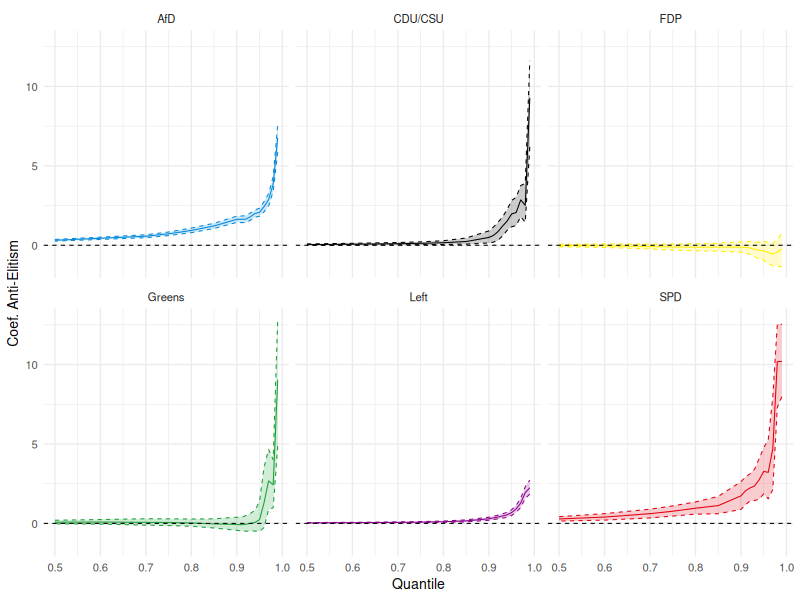

In [4]:
plot <- df |>
    filter(model_type == "views_elite", term == "elite") |>
    ggplot(aes(x = quantile, y = est, color = party, fill = party)) +
    geom_line() +
    geom_ribbon(aes(ymin = lower_ci, ymax = upper_ci), linetype = 2, alpha = 0.2) +
    geom_hline(yintercept = 0, color = "black", linetype = "dashed") +
    facet_wrap(~party, scales = "fixed") +
    labs(
        x = "Quantile",
        y = "Coef. Anti-Elitism"
    ) +
    scale_color_manual(values = cmap) +
    scale_fill_manual(values = cmap) +
    theme_minimal(base_size = 14) +
    theme(legend.position = "none")

path <- here("reports", "figures", "reg_views_elite.svg")
if (file.exists(path)) file.remove(path)
ggsave(path, plot, width = PLOT_WIDTH, height = PLOT_HEIGHT)
plot


# Likes Elite


In [ ]:
plot <- df |>
    filter(type == "likes", var == "elite") |>
    ggplot(aes(x = quantile, y = est, color = party, fill = party)) +
    geom_line() +
    geom_ribbon(aes(ymin = lower_ci, ymax = upper_ci), linetype = 2, alpha = 0.2) +
    geom_hline(yintercept = 0, color = "black", linetype = "dashed") +
    facet_wrap(~party, scales = "fixed") +
    labs(
        x = "Quantile",
        y = "Coef. Anti-Elitism"
    ) +
    scale_color_manual(values = cmap) +
    scale_fill_manual(values = cmap) +
    theme_minimal(base_size = 14) +
    theme(legend.position = "none")

path <- here("reports", "figures", "reg_likes_elite.svg")
if (file.exists(path)) file.remove(path)
ggsave(path, plot, width = PLOT_WIDTH, height = PLOT_HEIGHT)
plot


# Views Pplcentr


In [ ]:
plot <- df |>
    filter(type == "views", var == "pplcentr") |>
    ggplot(aes(x = quantile, y = est, color = party, fill = party)) +
    geom_line() +
    geom_ribbon(aes(ymin = lower_ci, ymax = upper_ci), linetype = 2, alpha = 0.2) +
    geom_hline(yintercept = 0, color = "black", linetype = "dashed") +
    facet_wrap(~party, scales = "fixed") +
    labs(
        x = "Quantile",
        y = "Coef. People-Centrism"
    ) +
    scale_color_manual(values = cmap) +
    scale_fill_manual(values = cmap) +
    theme_minimal(base_size = 14) +
    theme(legend.position = "none")

path <- here("reports", "figures", "reg_views_pplcentr.svg")
if (file.exists(path)) file.remove(path)
ggsave(path, plot, width = PLOT_WIDTH, height = PLOT_HEIGHT)
plot


# Likes Pplcentr


In [ ]:
plot <- df |>
    filter(type == "likes", var == "pplcentr") |>
    ggplot(aes(x = quantile, y = est, color = party, fill = party)) +
    geom_line() +
    geom_ribbon(aes(ymin = lower_ci, ymax = upper_ci), linetype = 2, alpha = 0.2) +
    geom_hline(yintercept = 0, color = "black", linetype = "dashed") +
    facet_wrap(~party, scales = "fixed") +
    labs(
        x = "Quantile",
        y = "Coef. People-Centrism"
    ) +
    scale_color_manual(values = cmap) +
    scale_fill_manual(values = cmap) +
    theme_minimal(base_size = 14) +
    theme(legend.position = "none")

path <- here("reports", "figures", "reg_likes_pplcentr.svg")
if (file.exists(path)) file.remove(path)
ggsave(path, plot, width = PLOT_WIDTH, height = PLOT_HEIGHT)
plot


In [ ]:
min(df$rhat)
max(df$rhat)
